# Redes Neuronales Convolucionales (CNN)
| IA 5.2 Computer Vision   
| FCEIA - UNR

En este cuaderno repasamos los conceptos fundamentales de las CNN aplicadas a vision por computadora: arquitectura **backbone-neck-head**, funcionamiento de un backbone convolucional con **ResNet50**, tipos de **datasets** y ejemplos practicos con modelos pre-entrenados.

# Librerias a utilizar

In [57]:
# !pip install torch torchvision

In [58]:
import ssl
import torch
import torch.nn as nn
import torchvision
import torchvision.models as models
import torchvision.transforms as T
from torchvision.models import ResNet50_Weights
import torchvision.datasets as datasets
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import urllib.request
import io
import os

print(f"PyTorch:      {torch.__version__}")
print(f"Torchvision:  {torchvision.__version__}")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Dispositivo:  {device}")

# --- Helpers para carga robusta de imagenes ---

def descargar_imagen(url, timeout=8):
    """Descarga una imagen. Intenta primero SSL normal, luego sin verificacion."""
    for verify_ssl in [True, False]:
        try:
            if verify_ssl:
                resp = urllib.request.urlopen(url, timeout=timeout)
            else:
                ctx = ssl.create_default_context()
                ctx.check_hostname = False
                ctx.verify_mode = ssl.CERT_NONE
                resp = urllib.request.urlopen(url, timeout=timeout, context=ctx)
            with resp:
                return Image.open(io.BytesIO(resp.read())).convert("RGB")
        except Exception:
            continue
    return None

def imagen_sintetica_escena():
    """Imagen sintetica con estructura (cielo, suelo, sol, objeto) para feature maps informativos."""
    arr = np.zeros((224, 224, 3), dtype=np.uint8)
    for i in range(130):
        t = i / 130
        arr[i, :] = [int(80*t), int(130*t), int(220 - 60*t)]
    arr[130:, :] = [55, 115, 45]
    Y, X = np.ogrid[:224, :224]
    arr[(Y-45)**2 + (X-175)**2 <= 28**2] = [255, 220, 40]
    mask_body = ((Y-145)/35)**2 + ((X-100)/55)**2 <= 1
    mask_head = ((Y-103)/26)**2 + ((X-132)/26)**2 <= 1
    arr[mask_body] = [155, 105, 55]
    arr[mask_head] = [155, 105, 55]
    arr[95:99, 121:125] = [25, 15, 10]
    arr[102:106, 128:133] = [75, 35, 25]
    return Image.fromarray(arr)

def cargar_imagen(ruta_local, url_fallback):
    """Carga imagen: archivo local → descarga internet → imagen sintetica."""
    if os.path.exists(ruta_local):
        print(f"[OK] Imagen local: {ruta_local}")
        return Image.open(ruta_local).convert("RGB")
    img = descargar_imagen(url_fallback)
    if img is not None:
        print(f"[OK] Descargada: {url_fallback}")
        return img
    print("[--] Sin imagen local ni internet → imagen sintetica")
    return imagen_sintetica_escena()

print("\nHelpers listos: cargar_imagen(), descargar_imagen(), imagen_sintetica_escena()")

PyTorch:      2.10.0+cpu
Torchvision:  0.25.0+cpu
Dispositivo:  cpu

Helpers listos: cargar_imagen(), descargar_imagen(), imagen_sintetica_escena()


---
# 1. Backbone, Neck y Head — La anatomia de una red de vision

Una red neuronal moderna para vision por computadora se organiza en 3 partes:

**Backbone** (columna vertebral): toma la imagen cruda y extrae caracteristicas. Va de pixels a features abstractas: bordes → texturas → formas → partes de objetos. Es la parte mas costosa computacionalmente.

**Neck** (cuello): opcional, conecta el backbone con la cabeza. Combina features de distintas escalas. Comun en deteccion de objetos (ej: FPN), pero en clasificacion simple generalmente no existe.

**Head** (cabeza): produce la prediccion final segun la tarea:
- **Clasificacion**: ¿que objeto es? (ej: "gato" con 95% de confianza)
- **Deteccion**: ¿donde estan los objetos y que son? (bounding boxes + clase)
- **Segmentacion**: ¿a que clase pertenece cada pixel?

```
Imagen → [BACKBONE] → features → [NECK] → [HEAD] → prediccion
224x224    extraccion    mapas     fusion    clas/det    clase/bbox
```

> En clasificacion simple: Imagen → [BACKBONE] → GlobalAvgPool → [HEAD: FC] → clase

In [59]:
# Cargamos ResNet50 sin pesos para ver solo la arquitectura
modelo = models.resnet50(weights=None)

print("=== ResNet50: Estructura Backbone-Neck-Head ===")
print()
print("[STEM] Entrada 224x224 → reduce a 56x56:")
print(f"  conv1:   {modelo.conv1}")
print(f"  maxpool: {modelo.maxpool}")
print()
print("[BACKBONE] Capas residuales:")
sizes = {1: "56x56", 2: "28x28", 3: "14x14", 4: "7x7"}
for i, layer in enumerate([modelo.layer1, modelo.layer2, modelo.layer3, modelo.layer4], 1):
    out_ch = layer[-1].conv3.out_channels if hasattr(layer[-1], "conv3") else layer[-1].conv2.out_channels
    print(f"  layer{i}: {len(layer)} bloques, {out_ch} canales, {sizes[i]}")
print()
print("[NECK] Global Average Pooling:")
print(f"  avgpool: reduce 7x7 → 1x1 (promedia espacialmente)")
print()
print("[HEAD] Clasificador (ImageNet = 1000 clases):")
print(f"  fc: {modelo.fc}")
print()
total = sum(p.numel() for p in modelo.parameters())
backbone_p = sum(p.numel() for n, p in modelo.named_parameters() if "fc" not in n)
head_p = sum(p.numel() for p in modelo.fc.parameters())
print(f"Total parametros:    {total:>12,}")
print(f"  Backbone+Neck:     {backbone_p:>12,} ({backbone_p/total*100:.1f}%)")
print(f"  Head (fc):         {head_p:>12,} ({head_p/total*100:.1f}%)")

=== ResNet50: Estructura Backbone-Neck-Head ===

[STEM] Entrada 224x224 → reduce a 56x56:
  conv1:   Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  maxpool: MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)

[BACKBONE] Capas residuales:
  layer1: 3 bloques, 256 canales, 56x56
  layer2: 4 bloques, 512 canales, 28x28
  layer3: 6 bloques, 1024 canales, 14x14
  layer4: 3 bloques, 2048 canales, 7x7

[NECK] Global Average Pooling:
  avgpool: reduce 7x7 → 1x1 (promedia espacialmente)

[HEAD] Clasificador (ImageNet = 1000 clases):
  fc: Linear(in_features=2048, out_features=1000, bias=True)

Total parametros:      25,557,032
  Backbone+Neck:       23,508,032 (92.0%)
  Head (fc):            2,049,000 (8.0%)


---
# 2. El Backbone Convolucional — Como funciona

El backbone convolucional aplica repetidamente tres operaciones basicas:

**1. Convolucion**: aplica un filtro (kernel) deslizante sobre la imagen. Cada kernel aprende a detectar un tipo de patron (borde, textura, forma). La red aprende automaticamente los mejores kernels durante el entrenamiento.

**2. Activacion ReLU**: `f(x) = max(0, x)`. Elimina valores negativos e introduce no-linealidad — sin ella, apilar capas no serviria de nada.

**3. Pooling**: reduce la resolucion espacial (alto × ancho) manteniendo lo importante. Hace la red mas eficiente y da invarianza traslacional parcial.

Esquema de transformaciones en ResNet50:
```
Imagen [3, 224, 224]
  → STEM  → [64,  112, 112]
  → layer1 → [256,  56,  56]
  → layer2 → [512,  28,  28]
  → layer3 → [1024, 14,  14]
  → layer4 → [2048,  7,   7]
  → AvgPool → [2048,  1,   1]
  → Flatten → [2048]
  → FC     → [1000]   <- num_clases
```
El numero de canales CRECE (mas features) y el espacio se REDUCE (mas contexto).

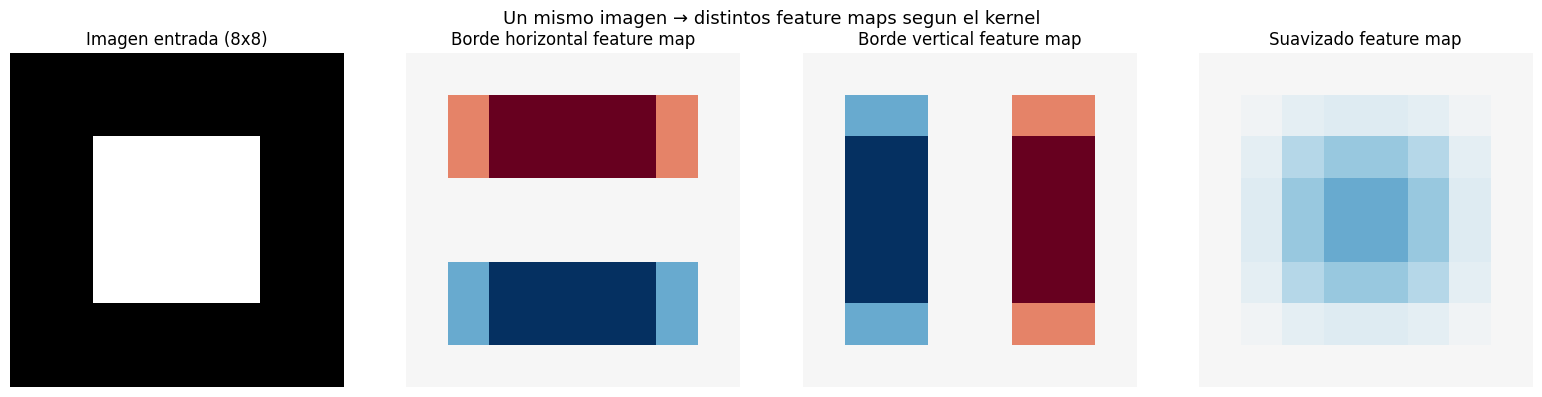

Cada filtro extrae un tipo diferente de caracteristica.
El backbone de ResNet50 tiene miles de filtros aprendidos automaticamente.


In [60]:
# Ejemplo: distintos kernels producen distintos feature maps
img_simple = torch.zeros(8, 8)
img_simple[2:6, 2:6] = 1.0  # cuadrado blanco en el centro

kernels = {
    "Borde horizontal": torch.tensor([[ 1., 2., 1.],
                                      [ 0., 0., 0.],
                                      [-1.,-2.,-1.]]),
    "Borde vertical":   torch.tensor([[-1., 0., 1.],
                                      [-2., 0., 2.],
                                      [-1., 0., 1.]]),
    "Suavizado":        torch.tensor([[ 1., 2., 1.],
                                      [ 2., 4., 2.],
                                      [ 1., 2., 1.]]) / 16.0,
}

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(img_simple.numpy(), cmap="gray")
axes[0].set_title("Imagen entrada (8x8)")
axes[0].axis("off")

for col, (nombre, kernel) in enumerate(kernels.items(), 1):
    conv = nn.Conv2d(1, 1, 3, padding=1, bias=False)
    with torch.no_grad():
        conv.weight = nn.Parameter(kernel.view(1, 1, 3, 3))
    out = conv(img_simple.unsqueeze(0).unsqueeze(0)).squeeze().detach().numpy()
    axes[col].imshow(out, cmap="RdBu", vmin=-2, vmax=2)
    axes[col].set_title(f"{nombre} feature map")
    axes[col].axis("off")

plt.suptitle("Un mismo imagen → distintos feature maps segun el kernel", fontsize=13)
plt.tight_layout()
plt.show()

print("Cada filtro extrae un tipo diferente de caracteristica.")
print("El backbone de ResNet50 tiene miles de filtros aprendidos automaticamente.")

## 2.1 Pooling y Activacion ReLU

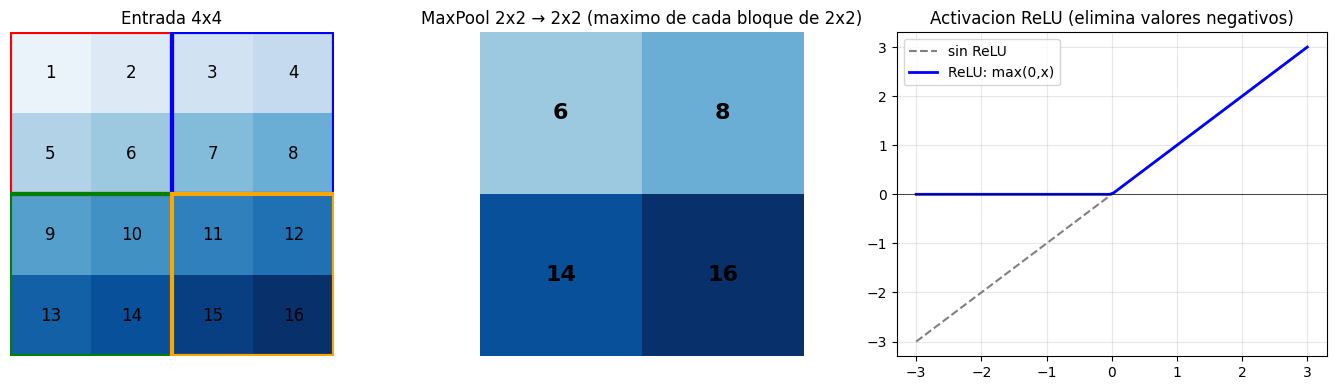

MaxPool: reduce resolucion a la mitad, conserva el valor mas alto de cada region.
ReLU: activa solo neuronas con respuesta positiva. Sin ella la red seria lineal.


In [61]:
# Visualizacion de MaxPooling y ReLU
img_pool = torch.arange(1, 17, dtype=torch.float32).view(1, 1, 4, 4)
max_pool = nn.MaxPool2d(kernel_size=2, stride=2)
out_max = max_pool(img_pool).squeeze().detach().numpy()

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Entrada
ax = axes[0]
ax.imshow(img_pool.squeeze().numpy(), cmap="Blues", vmin=0, vmax=16)
for i in range(4):
    for j in range(4):
        ax.text(j, i, f"{img_pool[0,0,i,j]:.0f}", ha="center", va="center", fontsize=12)
ax.set_title("Entrada 4x4"); ax.axis("off")
from matplotlib.patches import Rectangle
for color, (r1,r2,c1,c2) in zip(["red","blue","green","orange"],
                                  [(0,2,0,2),(0,2,2,4),(2,4,0,2),(2,4,2,4)]):
    ax.add_patch(Rectangle((c1-0.5,r1-0.5),c2-c1,r2-r1,fill=False,edgecolor=color,linewidth=3))

# MaxPool
ax = axes[1]
ax.imshow(out_max, cmap="Blues", vmin=0, vmax=16)
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{out_max[i,j]:.0f}", ha="center", va="center", fontsize=16, fontweight="bold")
ax.set_title("MaxPool 2x2 → 2x2 (maximo de cada bloque de 2x2)"); ax.axis("off")

# ReLU
x = torch.linspace(-3, 3, 100)
axes[2].plot(x.numpy(), x.numpy(), "--", color="gray", label="sin ReLU")
axes[2].plot(x.numpy(), torch.relu(x).numpy(), "b-", linewidth=2, label="ReLU: max(0,x)")
axes[2].axhline(0, color="black", linewidth=0.5)
axes[2].set_title("Activacion ReLU (elimina valores negativos)")
axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("MaxPool: reduce resolucion a la mitad, conserva el valor mas alto de cada region.")
print("ReLU: activa solo neuronas con respuesta positiva. Sin ella la red seria lineal.")

## 2.2 Feature maps: que detecta cada capa de ResNet50

[OK] Imagen local: ./data/YellowLabradorLooking_new.jpg


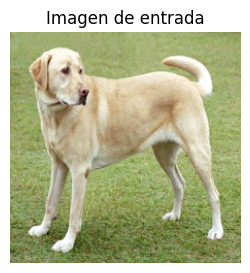

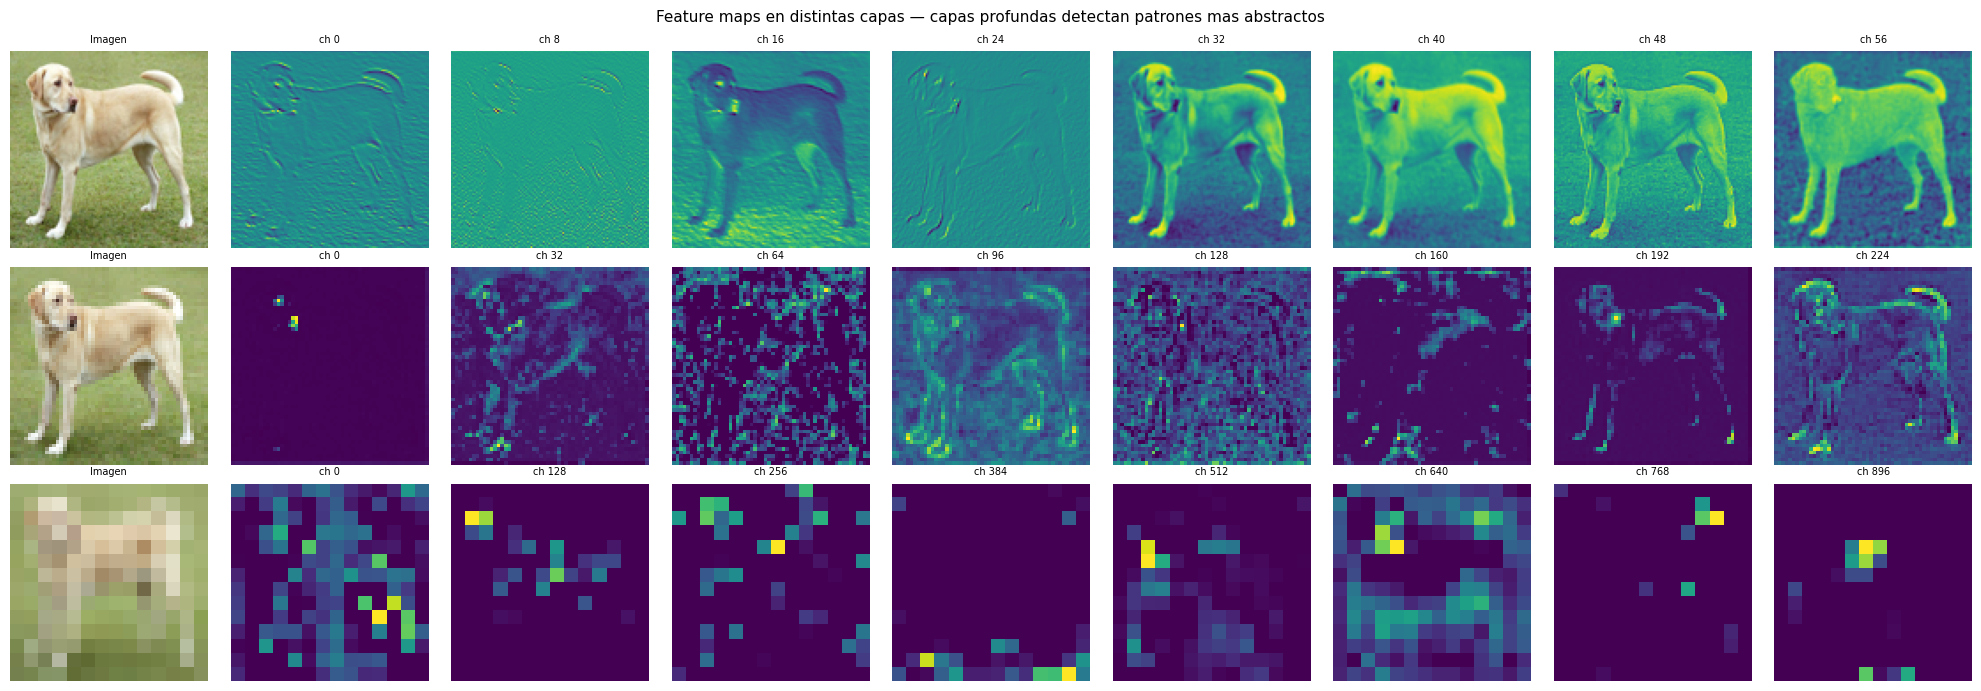

conv1 [64ch, 112x112]: shape = [64, 112, 112]
layer1 [256ch, 56x56]: shape = [256, 56, 56]
layer3 [1024ch, 14x14]: shape = [1024, 14, 14]


In [62]:
# Cargamos ResNet50 pre-entrenado
modelo_fm = models.resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)
modelo_fm.eval()

# Cargamos imagen: primero desde archivo local, luego internet, luego sintetica
def cargar_imagen(ruta_local, url_fallback):
    if os.path.exists(ruta_local):
        img = Image.open(ruta_local).convert("RGB")
        print(f"[OK] Imagen local: {ruta_local}")
        return img
    img = descargar_imagen(url_fallback)
    if img is not None:
        print(f"[OK] Imagen descargada: {url_fallback}")
        return img
    img = imagen_sintetica_escena()
    print("[--] Sin imagen local ni internet → imagen sintetica")
    return img

img_pil_demo = cargar_imagen(
    ruta_local="./data/YellowLabradorLooking_new.jpg",
    url_fallback="https://upload.wikimedia.org/wikipedia/commons/2/26/YellowLabradorLooking_new.jpg"
)

# Mostramos la imagen que usamos
plt.figure(figsize=(3, 3))
plt.imshow(img_pil_demo.resize((224, 224)))
plt.title("Imagen de entrada")
plt.axis("off")
plt.show()

# Preprocesamiento
transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
img_t = transform(img_pil_demo).unsqueeze(0)

# Hooks para capturar feature maps intermedios
feature_maps = {}
def make_hook(name):
    def hook(m, i, o): feature_maps[name] = o.detach()
    return hook

modelo_fm.conv1.register_forward_hook(make_hook("conv1 [64ch, 112x112]"))
modelo_fm.layer1.register_forward_hook(make_hook("layer1 [256ch, 56x56]"))
modelo_fm.layer3.register_forward_hook(make_hook("layer3 [1024ch, 14x14]"))

with torch.no_grad():
    _ = modelo_fm(img_t)

# Visualizamos 8 canales por capa
fig, axes = plt.subplots(3, 9, figsize=(20, 7))
for fila, (nombre, fmap) in enumerate(feature_maps.items()):
    fmap_np = fmap[0].numpy()
    spatial = fmap_np.shape[1]
    img_r = np.array(img_pil_demo.resize((spatial, spatial)))
    axes[fila, 0].imshow(img_r)
    axes[fila, 0].set_ylabel(nombre, fontsize=7)
    axes[fila, 0].set_title("Imagen", fontsize=7)
    axes[fila, 0].axis("off")
    step = max(1, fmap_np.shape[0] // 8)
    for col in range(8):
        ch = col * step
        fm = fmap_np[ch]
        fm_norm = (fm - fm.min()) / (fm.max() - fm.min() + 1e-8)
        axes[fila, col+1].imshow(fm_norm, cmap="viridis")
        axes[fila, col+1].set_title(f"ch {ch}", fontsize=7)
        axes[fila, col+1].axis("off")

plt.suptitle("Feature maps en distintas capas — capas profundas detectan patrones mas abstractos", fontsize=11)
plt.tight_layout()
plt.show()

for nombre, fmap in feature_maps.items():
    print(f"{nombre}: shape = {list(fmap.shape[1:])}")

---
# 3. ResNet50 — Bloques Residuales y Skip Connections

**El problema de las redes muy profundas**: al apilar muchas capas el gradiente se "desvanece" durante el backpropagation y la red deja de aprender bien.

**La solucion de ResNet** (He et al., 2015): los **bloques residuales** agregan una conexion directa (skip connection) que suma la entrada con la salida del bloque:

```
Entrada x
    |
    +--------→ [Conv1x1 → BN → ReLU → Conv3x3 → BN → ReLU → Conv1x1 → BN]
    |                                                                      |
    +----------------------------------------------------------------------+
                                                                           ↓
                                                                     ReLU(resultado + x)
```

El bloque aprende la **diferencia** (residuo) respecto a la identidad: `F(x) = H(x) - x`, lo que es mucho mas facil de aprender que `H(x)` directamente.

**Resultado**: ResNet50 tiene 50 capas y puede entrenarse sin problemas. Con solo 25M parametros logra >76% en ImageNet.

> ResNet50 = 1 stem + 16 bloques bottleneck (cada bloque tiene 3 convs) + 1 fc

In [63]:
# Exploramos un bloque bottleneck de ResNet50
modelo_arch = models.resnet50(weights=None)
bloque = modelo_arch.layer1[0]

print("=== Bloque Bottleneck de layer1[0] ===")
print()
print("Shortcut (conexion directa):")
print(f"  {bloque.downsample}")
print()
print("Rama principal (bottleneck 1x1 → 3x3 → 1x1):")
print(f"  conv1 (1x1): {bloque.conv1}  <- reduce canales (cuello de botella)")
print(f"  bn1 + relu")
print(f"  conv2 (3x3): {bloque.conv2}  <- operacion espacial")
print(f"  bn2 + relu")
print(f"  conv3 (1x1): {bloque.conv3}  <- expande canales de nuevo")
print(f"  bn3")
print()
print("Salida = ReLU(conv3_out + shortcut(x))")
print()

params_bloque = sum(p.numel() for p in bloque.parameters())
print(f"Parametros en este bloque: {params_bloque:,}")
print()
print("Bloques por capa en ResNet50:")
for i, layer in enumerate([modelo_arch.layer1, modelo_arch.layer2,
                             modelo_arch.layer3, modelo_arch.layer4], 1):
    p = sum(par.numel() for par in layer.parameters())
    print(f"  layer{i}: {len(layer)} bloques — {p:,} parametros")

=== Bloque Bottleneck de layer1[0] ===

Shortcut (conexion directa):
  Sequential(
  (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
  (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
)

Rama principal (bottleneck 1x1 → 3x3 → 1x1):
  conv1 (1x1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)  <- reduce canales (cuello de botella)
  bn1 + relu
  conv2 (3x3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)  <- operacion espacial
  bn2 + relu
  conv3 (1x1): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)  <- expande canales de nuevo
  bn3

Salida = ReLU(conv3_out + shortcut(x))

Parametros en este bloque: 75,008

Bloques por capa en ResNet50:
  layer1: 3 bloques — 215,808 parametros
  layer2: 4 bloques — 1,219,584 parametros
  layer3: 6 bloques — 7,098,368 parametros
  layer4: 3 bloques — 14,964,736 parametros


# 4. Datasets — Que son y tipos

Un **dataset** es una coleccion de datos etiquetados para entrenar y evaluar modelos. La calidad del dataset determina el techo de rendimiento.

## Tipos segun la tarea

| Tipo de anotacion | Que se anota | Ejemplo de dataset |
|---|---|---|
| **Clasificacion** | Una etiqueta por imagen | CIFAR-10, ImageNet |
| **Deteccion** | Bounding boxes + clase por objeto | COCO, Pascal VOC |
| **Segmentacion semantica** | Clase por pixel | Cityscapes, ADE20K |
| **Segmentacion de instancia** | Mascara individual por objeto | COCO (con masks) |
| **Keypoints** | Puntos clave (articulaciones, landmarks) | COCO-Pose, 300W |

## Datasets clasicos

| Dataset | Imagenes | Clases | Uso tipico |
|---|---|---|---|
| **MNIST** | 70K | 10 (digitos) | Clasificacion, benchmark inicial |
| **CIFAR-10** | 60K (32x32) | 10 | Clasificacion, investigacion |
| **ImageNet** | 14M | 1000 | Pre-entrenamiento de backbones |
| **COCO** | 330K | 80 | Deteccion + segmentacion |
| **Pascal VOC** | 11K | 20 | Deteccion |

## Particiones estandar

| Particion | Porcentaje tipico | Para que se usa |
|---|---|---|
| **Train** | 70-80% | Entrenar el modelo |
| **Validation** | 10-15% | Ajustar hiperparametros, monitorear |
| **Test** | 10-15% | Evaluacion final (no tocar hasta el final) |

Descargando CIFAR-10...


c:\Users\cferrucci.WIENER-LAB\Documents\Projects\facultad\IA5.2_Computer_Vision\.venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Total imagenes (train): 50000
Tamano de imagen: torch.Size([3, 32, 32])  (canales × alto × ancho)
Clases: ['avion', 'auto', 'pajaro', 'gato', 'ciervo', 'perro', 'rana', 'caballo', 'barco', 'camion']


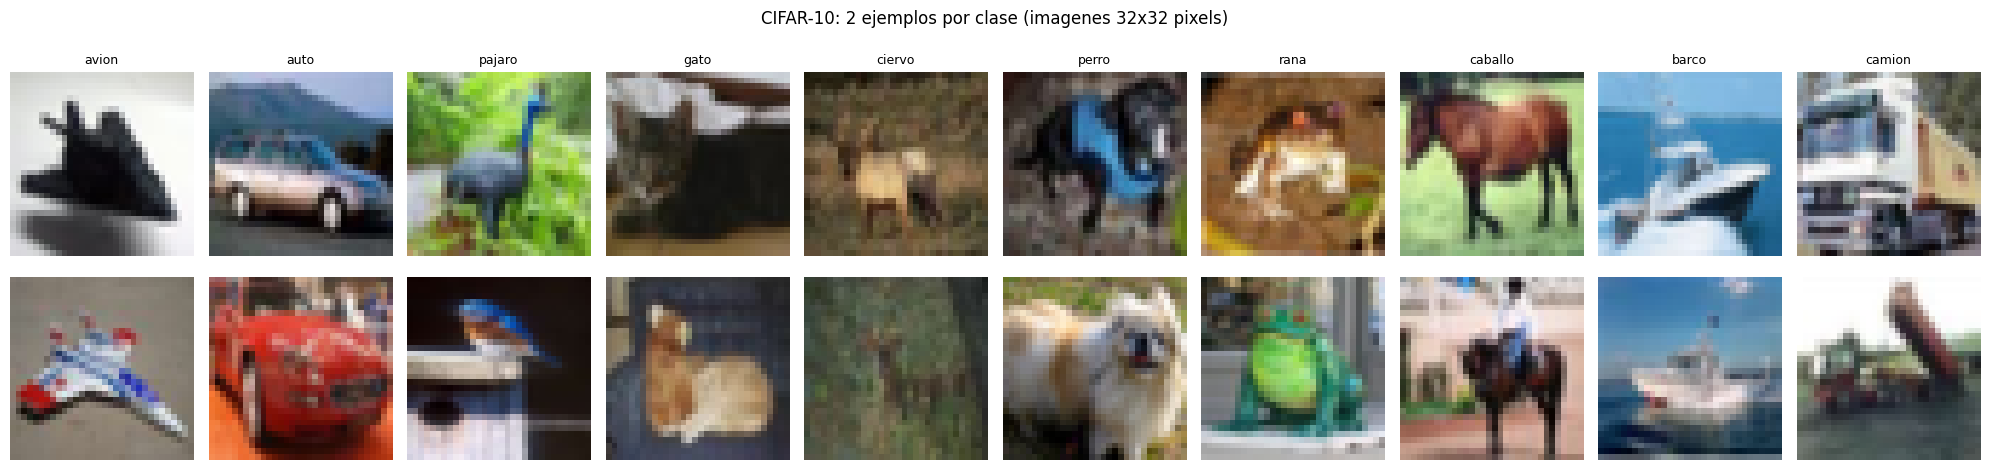

Distribucion de clases (train):
     avion:  5000 #########################
      auto:  5000 #########################
    pajaro:  5000 #########################
      gato:  5000 #########################
    ciervo:  5000 #########################
     perro:  5000 #########################
      rana:  5000 #########################
   caballo:  5000 #########################
     barco:  5000 #########################
    camion:  5000 #########################


In [66]:
# CIFAR-10: dataset de clasificacion con 10 clases
# 60.000 imagenes 32x32 pixels a color

transform_cifar = T.Compose([T.ToTensor()])

print("Descargando CIFAR-10...")
cifar10 = datasets.CIFAR10(root="./data", train=True, download=True, transform=transform_cifar)

CLASES = ["avion", "auto", "pajaro", "gato", "ciervo",
           "perro", "rana", "caballo", "barco", "camion"]

print(f"Total imagenes (train): {len(cifar10)}")
print(f"Tamano de imagen: {cifar10[0][0].shape}  (canales × alto × ancho)")
print(f"Clases: {CLASES}")

# Buscamos 2 ejemplos por clase
indices_por_clase = {i: [] for i in range(10)}
for idx, (img, label) in enumerate(cifar10):
    if len(indices_por_clase[label]) < 2:
        indices_por_clase[label].append(idx)
    if all(len(v) >= 2 for v in indices_por_clase.values()):
        break

fig, axes = plt.subplots(2, 10, figsize=(20, 5))
for col, (clase_id, idxs) in enumerate(indices_por_clase.items()):
    for fila, idx in enumerate(idxs[:2]):
        img, _ = cifar10[idx]
        axes[fila, col].imshow(img.permute(1, 2, 0).numpy())
        if fila == 0:
            axes[fila, col].set_title(CLASES[clase_id], fontsize=9)
        axes[fila, col].axis("off")

plt.suptitle("CIFAR-10: 2 ejemplos por clase (imagenes 32x32 pixels)", fontsize=12)
plt.tight_layout()
plt.show()

# Distribucion de clases
conteo = [0] * 10
for _, label in cifar10:
    conteo[label] += 1
print("Distribucion de clases (train):")
for clase, count in zip(CLASES, conteo):
    barra = "#" * (count // 200)
    print(f"  {clase:>8}: {count:5d} {barra}")

# 5. ResNet50 Pre-entrenado — Ejemplo Practico de Clasificacion

ResNet50 entrenado en **ImageNet** puede reconocer **1000 categorias** de objetos comunes.

**Preprocesamiento obligatorio para ImageNet:**
```python
mean = [0.485, 0.456, 0.406]   # media de ImageNet por canal RGB
std  = [0.229, 0.224, 0.225]   # desvio estandar de ImageNet
```
El modelo ESPERA entradas con esta normalizacion. Si la normalizacion es incorrecta, las predicciones seran basura aunque la imagen sea correcta.

**Modo evaluacion**: siempre llamar `model.eval()` antes de inferencia. Esto:
- Desactiva Dropout
- Configura BatchNorm en modo estadistico (usa parametros aprendidos, no estadisticas del batch actual)

In [67]:
# Cargamos ResNet50 pre-entrenado
modelo_cls = models.resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)
modelo_cls.eval()

# Etiquetas de ImageNet (1000 clases)
try:
    import ssl as _ssl
    url_labels = "https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt"
    _ctx = _ssl.create_default_context()
    _ctx.check_hostname = False
    _ctx.verify_mode = _ssl.CERT_NONE
    with urllib.request.urlopen(url_labels, timeout=8, context=_ctx) as resp:
        etiquetas = [line.strip() for line in resp.read().decode("utf-8").splitlines()]
    print(f"Etiquetas cargadas: {len(etiquetas)} clases — primeras 5: {etiquetas[:5]}")
except Exception as e:
    etiquetas = [f"clase_{i}" for i in range(1000)]
    print(f"No se pudo descargar etiquetas ({e}) → usando nombres genericos")

# Preprocesamiento estandar de ImageNet
transform_imagenet = T.Compose([
    T.Resize(256),
    T.CenterCrop(224),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225])
])

# Imagenes: local → internet → sintetica
imagenes_cfg = [
    ("./data/YellowLabradorLooking_new.jpg",
     "https://upload.wikimedia.org/wikipedia/commons/2/26/YellowLabradorLooking_new.jpg",
     "perro"),
    ("./data/cute_cat.jpg",
     "https://upload.wikimedia.org/wikipedia/commons/thumb/4/43/Cute_cat.jpg/320px-Cute_cat.jpg",
     "gato"),
]

imagenes_pil = []
nombres = []
for ruta_local, url_fallback, nombre in imagenes_cfg:
    img = cargar_imagen(ruta_local, url_fallback)
    imagenes_pil.append(img)
    nombres.append(nombre)

# Clasificamos y mostramos Top-5
print("\n=== Predicciones Top-5 ===")
for img_pil, nombre in zip(imagenes_pil, nombres):
    img_t = transform_imagenet(img_pil).unsqueeze(0)
    with torch.no_grad():
        probs = torch.softmax(modelo_cls(img_t), dim=1)
    top5_probs, top5_idx = torch.topk(probs, k=5)
    print(f"\n[{nombre}]")
    for prob, idx in zip(top5_probs[0], top5_idx[0]):
        print(f"  {prob.item()*100:5.1f}%  {etiquetas[idx.item()]}")

Etiquetas cargadas: 1000 clases — primeras 5: ['tench', 'goldfish', 'great white shark', 'tiger shark', 'hammerhead']
[OK] Imagen local: ./data/YellowLabradorLooking_new.jpg
[OK] Imagen local: ./data/cute_cat.jpg

=== Predicciones Top-5 ===

[perro]
   52.4%  Labrador retriever
    7.2%  Chesapeake Bay retriever
    5.1%  golden retriever
    3.7%  dingo
    2.7%  bloodhound

[gato]
   57.4%  tiger cat
   22.4%  tabby
    7.2%  lynx
    3.2%  Egyptian cat
    3.1%  Persian cat


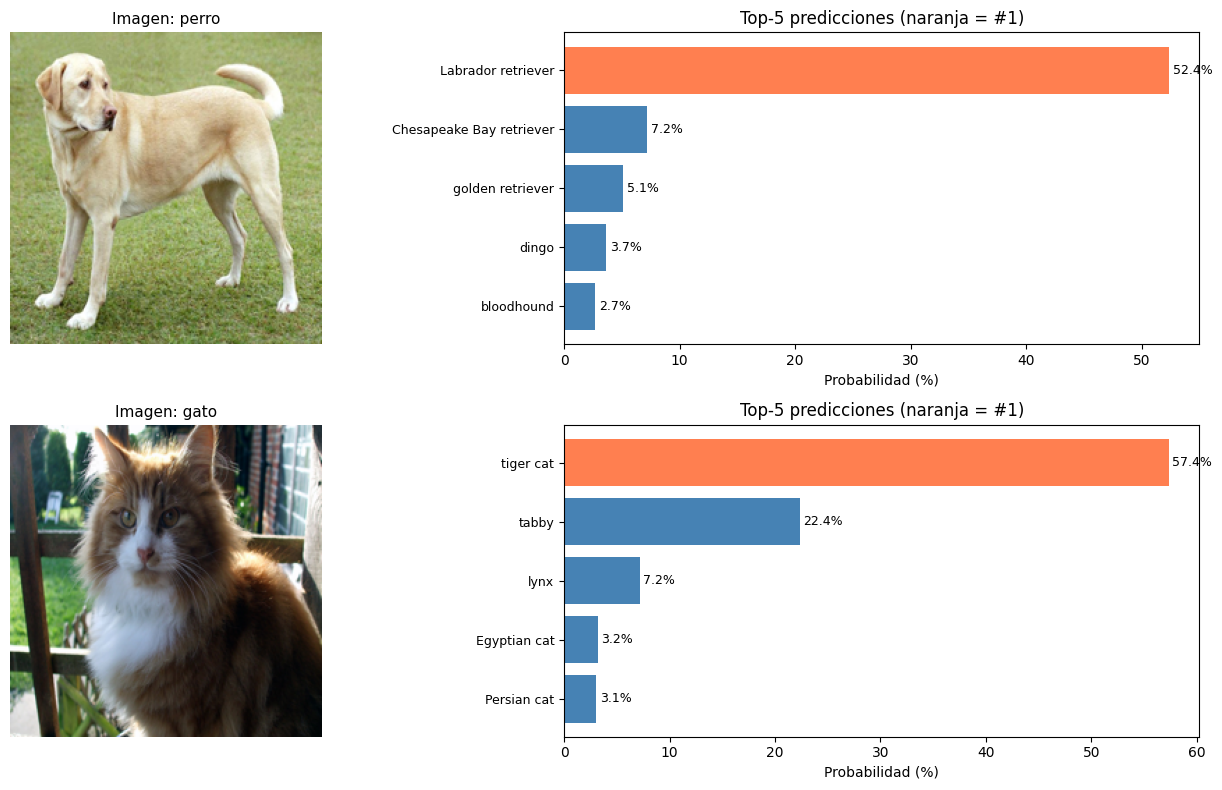

In [68]:
# Visualizamos predicciones con graficos de barras
fig, axes = plt.subplots(len(imagenes_pil), 2, figsize=(14, 4 * len(imagenes_pil)))
if len(imagenes_pil) == 1:
    axes = [axes]

for fila, (img_pil, nombre) in enumerate(zip(imagenes_pil, nombres)):
    img_t = transform_imagenet(img_pil).unsqueeze(0)
    with torch.no_grad():
        probs = torch.softmax(modelo_cls(img_t), dim=1)
    top5_probs, top5_idx = torch.topk(probs, k=5)

    axes[fila][0].imshow(img_pil.resize((224, 224)))
    axes[fila][0].set_title(f"Imagen: {nombre}", fontsize=11)
    axes[fila][0].axis("off")

    top5_etiq = [etiquetas[i.item()][:25] for i in top5_idx[0]]
    top5_vals = [p.item() * 100 for p in top5_probs[0]]
    colors = ["coral"] + ["steelblue"] * 4

    axes[fila][1].barh(range(5), top5_vals[::-1],
                       color=colors[::-1])
    axes[fila][1].set_yticks(range(5))
    axes[fila][1].set_yticklabels(top5_etiq[::-1], fontsize=9)
    axes[fila][1].set_xlabel("Probabilidad (%)")
    axes[fila][1].set_title("Top-5 predicciones (naranja = #1)")
    for i, val in enumerate(top5_vals[::-1]):
        axes[fila][1].text(val + 0.3, i, f"{val:.1f}%", va="center", fontsize=9)

plt.tight_layout()
plt.show()

---
# Ejercicios

## Ejercicio 1: Explorar la arquitectura de ResNet50

1. Listar todas las capas `nn.Conv2d` de `modelo_cls` usando `named_modules()`.
2. Para cada una mostrar: nombre, `in_channels`, `out_channels`, `kernel_size`.
3. Responder en una celda markdown:
   - ¿Cuantas capas Conv2d hay en total?
   - ¿Como evoluciona el numero de canales de salida a lo largo de la red?
   - ¿Que tamanio de kernel es el mas comun? ¿Por que creen que es asi?

In [69]:
# Ejercicio 1: Completar aqui

# 1-2. Listar capas Conv2d con sus parametros
# for nombre, modulo in modelo_cls.named_modules():
#     if isinstance(modulo, nn.Conv2d):
#         # TODO: imprimir nombre, in_channels, out_channels, kernel_size

# 3. Contar total de capas Conv2d
# n_conv = sum(1 for _, m in modelo_cls.named_modules() if isinstance(m, nn.Conv2d))
# print(f"Total Conv2d: {n_conv}")

### Solucion Ejercicio 1

In [70]:
# Solucion Ejercicio 1

print(f"{'Nombre':<42} {'in_ch':>6} {'out_ch':>7} {'kernel':>8}")
print("-" * 68)

canales_salida = []
kernels_count = {}
n_conv = 0

for nombre, modulo in modelo_cls.named_modules():
    if isinstance(modulo, nn.Conv2d):
        n_conv += 1
        ks = modulo.kernel_size[0]
        canales_salida.append(modulo.out_channels)
        kernels_count[ks] = kernels_count.get(ks, 0) + 1
        print(f"{nombre:<42} {modulo.in_channels:>6} {modulo.out_channels:>7} {str(modulo.kernel_size):>8}")

print()
print(f"Total capas Conv2d: {n_conv}")
print(f"Canales salida (primeras 10): {canales_salida[:10]}")
print(f"Canales min → max: {min(canales_salida)} → {max(canales_salida)}")
print(f"Kernels usados: {dict(sorted(kernels_count.items()))}")
print()
print("Analisis:")
print("- Canales CRECEN a lo largo de la red: 64 → 256 → 512 → 1024 → 2048")
print("- El kernel 1x1 es el mas comun: reduce/expande canales sin costo espacial")
print("- El kernel 3x3 hace la extraccion espacial real")
print("- Un solo kernel 7x7 al inicio (stem) para la imagen de entrada cruda")

Nombre                                      in_ch  out_ch   kernel
--------------------------------------------------------------------
conv1                                           3      64   (7, 7)
layer1.0.conv1                                 64      64   (1, 1)
layer1.0.conv2                                 64      64   (3, 3)
layer1.0.conv3                                 64     256   (1, 1)
layer1.0.downsample.0                          64     256   (1, 1)
layer1.1.conv1                                256      64   (1, 1)
layer1.1.conv2                                 64      64   (3, 3)
layer1.1.conv3                                 64     256   (1, 1)
layer1.2.conv1                                256      64   (1, 1)
layer1.2.conv2                                 64      64   (3, 3)
layer1.2.conv3                                 64     256   (1, 1)
layer2.0.conv1                                256     128   (1, 1)
layer2.0.conv2                                128     128   

## Ejercicio 2: Visualizar los filtros aprendidos por ResNet50

En la Seccion 2 vimos kernels diseñados a mano (borde horizontal, vertical, suavizado). En este ejercicio vamos a ver los **64 filtros reales** que ResNet50 aprendio en su primera capa (`conv1`).

**Pasos:**
1. Acceder a los pesos de `conv1`: `modelo_cls.conv1.weight.data` — shape `[64, 3, 7, 7]`
2. Para cada filtro, normalizar sus valores al rango [0, 1]
3. Mostrar los 64 filtros en una grilla 8×8
4. Responder en markdown: ¿Que patrones reconoces? ¿Se parecen a los kernels manuales?

**Pista**: `f_norm = (f - f.min()) / (f.max() - f.min() + 1e-8)` para normalizar, y `f.permute(1, 2, 0)` para pasar de `[3, 7, 7]` a `[7, 7, 3]` (formato imagen).

In [ ]:
# Ejercicio 2: Completar aqui

filtros = modelo_cls.conv1.weight.data  # [64, 3, 7, 7]

fig, axes = plt.subplots(8, 8, figsize=(12, 12))
for i, ax in enumerate(axes.flat):
    f = filtros[i].permute(1, 2, 0).numpy()  # [7, 7, 3]
    # TODO: normalizar f al rango [0, 1]
    # f_norm = ...

    # TODO: mostrar f_norm con imshow
    ax.axis("off")

plt.suptitle("Filtros aprendidos en conv1 de ResNet50", fontsize=12)
plt.tight_layout()
plt.show()

### Solucion Ejercicio 2

In [ ]:
# Solucion Ejercicio 2

filtros = modelo_cls.conv1.weight.data  # [64, 3, 7, 7]

fig, axes = plt.subplots(8, 8, figsize=(12, 12))
for i, ax in enumerate(axes.flat):
    f = filtros[i].permute(1, 2, 0).numpy()  # [7, 7, 3]
    f_norm = (f - f.min()) / (f.max() - f.min() + 1e-8)
    ax.imshow(f_norm)
    ax.axis("off")

plt.suptitle("64 filtros aprendidos en conv1 de ResNet50 (kernel 7x7, 3 canales RGB)", fontsize=12)
plt.tight_layout()
plt.show()

print("Cada imagen es un filtro de 7x7 pixeles con 3 canales RGB.")
print("Se pueden ver orientaciones de bordes, patrones de color y frecuencias.")
print("Son similares a los kernels manuales del principio, pero aprendidos automaticamente.")

## Ejercicio 3: Efecto del preprocesamiento en las predicciones

El preprocesamiento correcto es **critico** para que ResNet50 funcione. En este ejercicio comparamos tres variantes.

**Pasos:**
1. Usar una de las imagenes de `imagenes_pil`.
2. Crear 3 transformaciones:
   - `prep_correcto`: estandar ImageNet (Resize 256 → CenterCrop 224 → ToTensor → Normalize con `[0.485,0.456,0.406]` y `[0.229,0.224,0.225]`)
   - `prep_sin_norm`: igual pero sin `Normalize`
   - `prep_norm_mal`: `Normalize(mean=[0.5,0.5,0.5], std=[0.5,0.5,0.5])` (incorrecto)
3. Para cada una, clasificar con `modelo_cls` y mostrar las Top-3 predicciones + probabilidades + rango del tensor.
4. Responder en markdown: ¿Como afecta la normalizacion incorrecta a las predicciones? ¿Por que?

In [73]:
# Ejercicio 3: Completar aqui

preprocs = {
    "Correcto (ImageNet)": None,       # TODO: completar
    "Sin normalizacion":   None,       # TODO: completar
    "Norm incorrecta":     None,       # TODO: completar
}

# Para cada preprocesamiento:
# img_t = preprocesamiento(imagenes_pil[0]).unsqueeze(0)
# with torch.no_grad():
#     probs = torch.softmax(modelo_cls(img_t), dim=1)
# top3_probs, top3_idx = torch.topk(probs, k=3)
# Mostrar top-3 y rango del tensor

### Solucion Ejercicio 3

In [74]:
# Solucion Ejercicio 3

preprocs = {
    "Correcto (ImageNet)": T.Compose([
        T.Resize(256), T.CenterCrop(224), T.ToTensor(),
        T.Normalize(mean=[0.485, 0.456, 0.406],
                    std=[0.229, 0.224, 0.225])
    ]),
    "Sin normalizacion": T.Compose([
        T.Resize(256), T.CenterCrop(224), T.ToTensor()
    ]),
    "Norm incorrecta (0.5, 0.5)": T.Compose([
        T.Resize(256), T.CenterCrop(224), T.ToTensor(),
        T.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
    ]),
}

img_prueba = imagenes_pil[0]
nombre_prueba = nombres[0]
print(f"=== Imagen: {nombre_prueba} ===")

for nombre_prep, prep in preprocs.items():
    img_t = prep(img_prueba).unsqueeze(0)
    with torch.no_grad():
        probs = torch.softmax(modelo_cls(img_t), dim=1)
    top3_probs, top3_idx = torch.topk(probs, k=3)

    print(f"[{nombre_prep}]")
    for prob, idx in zip(top3_probs[0], top3_idx[0]):
        etiq = etiquetas[idx.item()]
        print(f"  {prob.item()*100:5.1f}%  {etiq}")
    tn = img_t.squeeze(0)
    print(f"  Rango tensor entrada: [{tn.min():.3f}, {tn.max():.3f}]  media: {tn.mean():.3f}")
    print()

print("=" * 60)
print("Conclusion:")
print("- Correcto: predicciones con alta confianza y clase correcta.")
print("- Sin normalizacion: tensor en rango [0,1] en vez de ~[-2,2].")
print("  El modelo fue entrenado con datos normalizados -> predicciones degradadas.")
print("- Norm incorrecta: shift en la distribucion de entrada.")
print("  Las predicciones cambian significativamente.")
print()
print("La normalizacion alinea la distribucion de los datos de entrada")
print("con la distribucion que el modelo vio durante el entrenamiento.")

=== Imagen: perro ===
[Correcto (ImageNet)]
   52.4%  Labrador retriever
    7.2%  Chesapeake Bay retriever
    5.1%  golden retriever
  Rango tensor entrada: [-1.983, 2.640]  media: 0.731

[Sin normalizacion]
   36.0%  Chesapeake Bay retriever
   26.7%  Labrador retriever
    6.0%  kuvasz
  Rango tensor entrada: [0.004, 1.000]  media: 0.614

[Norm incorrecta (0.5, 0.5)]
   43.9%  Chesapeake Bay retriever
   29.1%  Labrador retriever
    4.0%  golden retriever
  Rango tensor entrada: [-0.992, 1.000]  media: 0.229

Conclusion:
- Correcto: predicciones con alta confianza y clase correcta.
- Sin normalizacion: tensor en rango [0,1] en vez de ~[-2,2].
  El modelo fue entrenado con datos normalizados -> predicciones degradadas.
- Norm incorrecta: shift en la distribucion de entrada.
  Las predicciones cambian significativamente.

La normalizacion alinea la distribucion de los datos de entrada
con la distribucion que el modelo vio durante el entrenamiento.
